In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load the training dataset
train_path = "../Data/train_data.csv" 
train_df = pd.read_csv(train_path)

In [4]:
# Convert year columns to numeric
year_columns = [col for col in train_df.columns if '[YR' in col]
train_df[year_columns] = train_df[year_columns].apply(pd.to_numeric, errors='coerce')

In [5]:
# Summary statistics
print("\nSummary Statistics:")
print(train_df.describe())


Summary Statistics:
       2002 [YR2002]  2003 [YR2003]  2004 [YR2004]  2005 [YR2005]  \
count    1655.000000    1655.000000    1655.000000    1655.000000   
mean      559.099003     886.800954     599.206635     631.992811   
std      3842.168456    4504.850552    4175.463487    4434.322048   
min         0.000000       0.000000       0.000000       0.000000   
25%         3.100000       3.500000       2.786249       2.500000   
50%        28.464273      24.328507      26.211325      23.251183   
75%        86.400000      96.000000      92.278449      92.634000   
max     94000.000000   89000.000000   85000.000000   79000.000000   

       2006 [YR2006]  2007 [YR2007]  2008 [YR2008]  2009 [YR2009]  \
count    1655.000000    1655.000000    1655.000000    1655.000000   
mean      631.741996     894.068395     680.198627     654.255712   
std      4502.397135    4911.931277    4856.064668    4835.829574   
min         0.000000       0.000000       0.000000       0.000000   
25%         

- The high standard deviations and gap between the mean and max values show that a few high-income countries dominate healthcare spending, and many low-income countries have minimal resources.
- The bottom 25% of values remain near zero, showing that a large portion of the world still lacks access to essential healthcare.
- The mean increases over time, but certain years (e.g., 2009, 2011, 2014) show declines, maybe due to economic instability or policy shifts impacting healthcare investments.
- Healthcare improvements are not evenly distributed. High-income countries continue to advance, and low-income countries struggles.

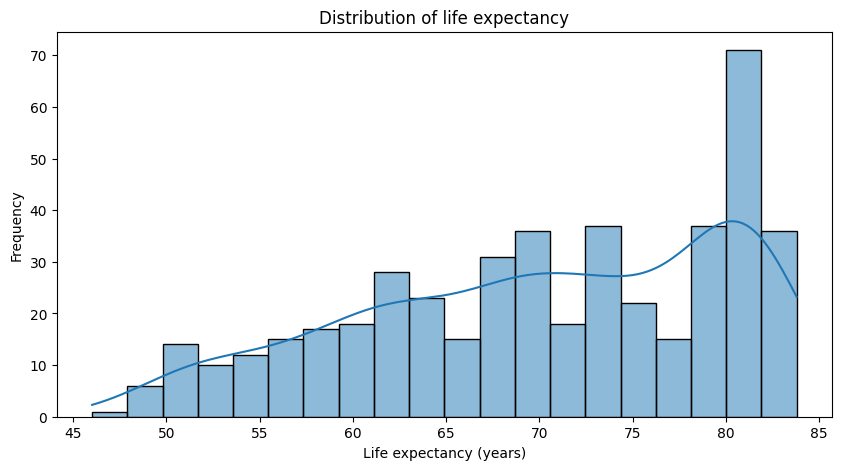

In [6]:
# Distribution of life expectancy 
life_expectancy_df = train_df[train_df['Series Name'] == 'Life expectancy at birth, total (years)']

# Reshape the data
life_expectancy_melted = life_expectancy_df.melt(id_vars=['Series Name', 'Country Name'], 
                                                 value_vars=year_columns, 
                                                 var_name="Year", 
                                                 value_name="Life Expectancy")

# Convert 'year' to numeric 
life_expectancy_melted['Year'] = life_expectancy_melted['Year'].str.extract('(\d+)').astype(int)

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(life_expectancy_melted['Life Expectancy'].dropna(), bins=20, kde=True)
plt.title('Distribution of life expectancy')
plt.xlabel('Life expectancy (years)')
plt.ylabel('Frequency')
plt.show()

- The distribution of life expectancy shows a right-skewed pattern.
- The distribution shows two clusters, one around 60–70 years (likely middle and low-income countries) and another near 80 years (high-income countries). 
- Life expectancy is not evenly distributed globally, with low-income countries significantly behind and struggle with low longevity.

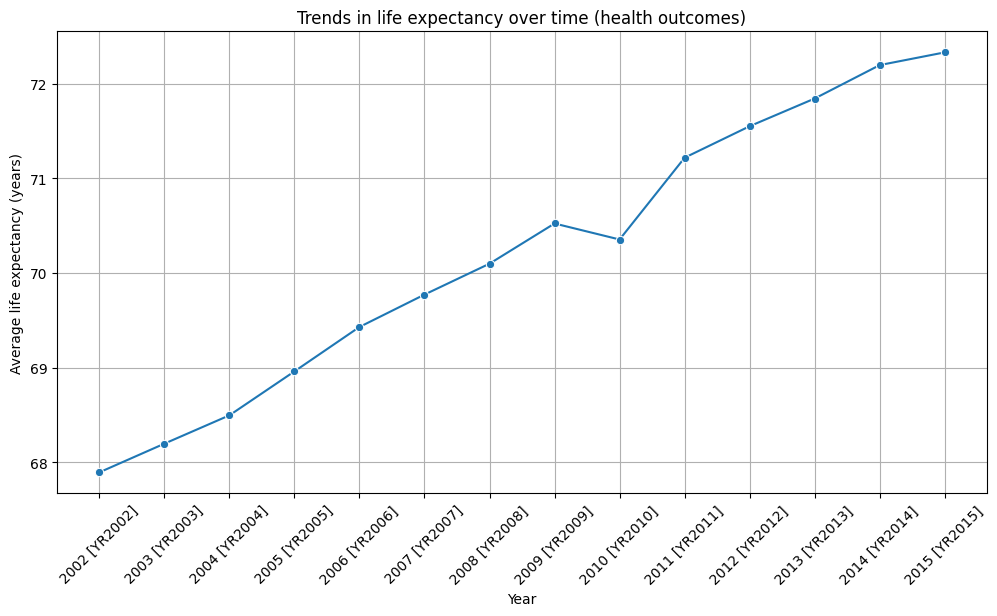

In [7]:
# Trends in life expectancy over time (health outcomes)

# Convert year columns to numeric
year_columns = [col for col in train_df.columns if '[YR' in col]
train_df[year_columns] = train_df[year_columns].apply(pd.to_numeric, errors='coerce')

# Filter  health outcomes category and life expectancy indicator and reshape data
health_outcomes_df = train_df[(train_df['Category'] == 'Health Outcomes') & 
                              (train_df['Series Name'] == 'Life expectancy at birth, total (years)')]
life_expectancy_melted = health_outcomes_df.melt(id_vars=['Country Name'], 
                                                 value_vars=year_columns, 
                                                 var_name="Year", 
                                                 value_name="Life Expectancy")

# Average life expectancy per year
average_life_expectancy = life_expectancy_melted.groupby('Year')['Life Expectancy'].mean()

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(x=average_life_expectancy.index, y=average_life_expectancy.values, marker='o', linestyle='-')

plt.title("Trends in life expectancy over time (health outcomes)")
plt.xlabel("Year")
plt.ylabel("Average life expectancy (years)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


- Life expectancy rose from approximately 68 years in 2002 to around 72 years in 2015, maybe due to advancements in healthcare access or medical technology. However, there is a noticeable decline around 2010, which may reflect economic disruptions following the 2008 financial crisis, but it rebounded quickly.
- There is a steeper increase after 2010, which suggest that post-crisis healthcare policies may have played a role in improving longevity.

                         count       mean       std        min        25%  \
Income Group                                                                
High-Income Countries    154.0  80.683746  1.544487  76.765854  79.761585   
Low-Income Countries     154.0  59.630481  5.691596  46.019000  55.528000   
Middle-Income Countries  154.0  70.300214  4.996187  53.980000  68.576250   

                               50%        75%        max  
Income Group                                              
High-Income Countries    80.870732  81.797927  83.793902  
Low-Income Countries     60.492500  63.622750  70.491000  
Middle-Income Countries  70.832000  73.907500  76.760000  


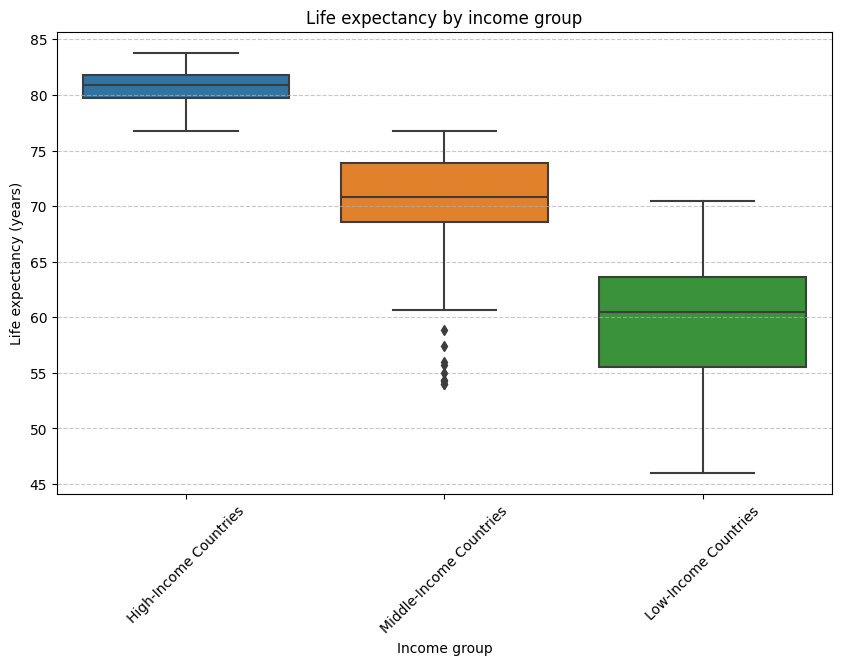

In [8]:
# Life expectancy by income group
# Filter for only life expectancy
life_expectancy_df = train_df[train_df['Series Name'] == 'Life expectancy at birth, total (years)']

# Reshape data
life_expectancy_melted = life_expectancy_df.melt(id_vars=['Country Name', 'Income Group'], 
                                                 value_vars=year_columns, 
                                                 var_name="Year", 
                                                 value_name="Life Expectancy")


# Summary statistics
summary_stats = life_expectancy_melted.groupby('Income Group')['Life Expectancy'].describe()
print(summary_stats)

# Box plot
plt.figure(figsize=(10,6))
sns.boxplot(x='Income Group', y='Life Expectancy', data=life_expectancy_melted)

plt.title("Life expectancy by income group")
plt.xlabel("Income group")
plt.ylabel("Life expectancy (years)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


- High-income countries have the highest median life expectancy around 81 years with low variability, which indicate they have consistent healthcare access and quality.
- Middle-income countries have a median of about 71 years and show more variation, with some countries having life expectancies closer to low-income countries..
- Low-income countries have the lowest median at approximately 60 years, with the widest range, from 46 to 70 years.
- Low and middle-income countries show larger spreads, with many outliers observed in middle-income countries, meaning life expectancy varies widely within these groups, whcih reflects significant disparities in healthcare access and development.

                         count       mean       std        min        25%  \
Income Group                                                                
High-Income Countries     14.0  80.683746  0.912001  79.152949  79.999296   
Low-Income Countries      14.0  59.630481  2.370870  55.797091  57.902091   
Middle-Income Countries   14.0  70.300214  1.209103  68.724727  69.329159   

                               50%        75%        max  
Income Group                                              
High-Income Countries    80.744789  81.414956  81.933836  
Low-Income Countries     59.482773  61.688955  62.987818  
Middle-Income Countries  70.218636  71.303386  72.169364  


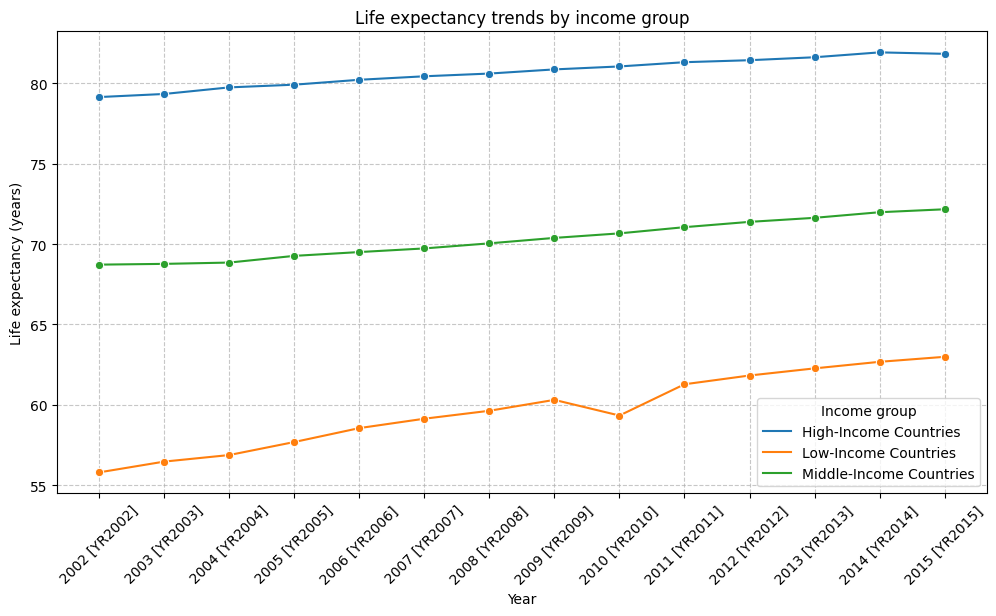

In [9]:
# Life expectancy trends by income group
# Reshape to long format
life_expectancy_melted = life_expectancy_df.melt(id_vars=['Income Group'], 
                                                 value_vars=year_columns, 
                                                 var_name="Year", 
                                                 value_name="Life Expectancy")

# Average life expectancy per year for each income group
avg_life_expectancy_by_income = life_expectancy_melted.groupby(['Year', 'Income Group'])['Life Expectancy'].mean().reset_index()

# Summary statistics
summary_stats = avg_life_expectancy_by_income.groupby('Income Group')['Life Expectancy'].describe()
print(summary_stats)

# Line plot
plt.figure(figsize=(12,6))
sns.lineplot(data=avg_life_expectancy_by_income, x='Year', y='Life Expectancy', hue='Income Group', marker='o')

plt.title("Life expectancy trends by income group")
plt.xlabel("Year")
plt.ylabel("Life expectancy (years)")
plt.legend(title="Income group")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


- The graph shows a clear upward trend in life expectancy across all income groups from 2002 to 2015. 
- High-income countries consistently maintain the highest life expectancy, with a relatively small spread with mean around 80.7 years and standard deviation around 0.91.
- Middle-income countries show a moderate upward trend, averaging around 70.3 years, with slightly more variation. 
- Low-income countries start at a much lower baseline but show the steepest increase over time. However, there is a noticeable dip around 2010, which may reflect external factors that disrupted healthcare systems, but they rebounded quickly continued their upward trend in life expectancy.


In [10]:
# Outliers
# Average life expectancy for each country
country_avg_life_expectancy = life_expectancy_df.set_index('Country Name')[year_columns].mean(axis=1).reset_index()
country_avg_life_expectancy.columns = ['Country Name', 'Average Life Expectancy']

# Top 5 and bottom 5 Countries
top_5_countries = country_avg_life_expectancy.nlargest(5, 'Average Life Expectancy')
bottom_5_countries = country_avg_life_expectancy.nsmallest(5, 'Average Life Expectancy')

# Results
print("\nTop 5 countries with highest life expectancy:")
print(top_5_countries)

print("\nBottom 5 countries with lowest life expectancy:")
print(bottom_5_countries)



Top 5 countries with highest life expectancy:
   Country Name  Average Life Expectancy
2         Japan                82.644843
8   Switzerland                81.931882
9         Italy                81.600174
4     Australia                81.376132
10       Sweden                81.175610

Bottom 5 countries with lowest life expectancy:
    Country Name  Average Life Expectancy
22       Nigeria                50.305071
29    Mozambique                53.740857
27        Uganda                55.824929
23      Ethiopia                57.870357
13  South Africa                58.001286


The 40+ year gap between the highest and lowest life expectancy countries highlights deep global health inequities. High-life-expectancy countries remain stable around 83 years, and low-life-expectancy countries fall below 60 years and show much greater variation. This contrast underscores systemic disparities, where certain countries consistently face challenges in healthcare access that ignificantly lower life expectancy.

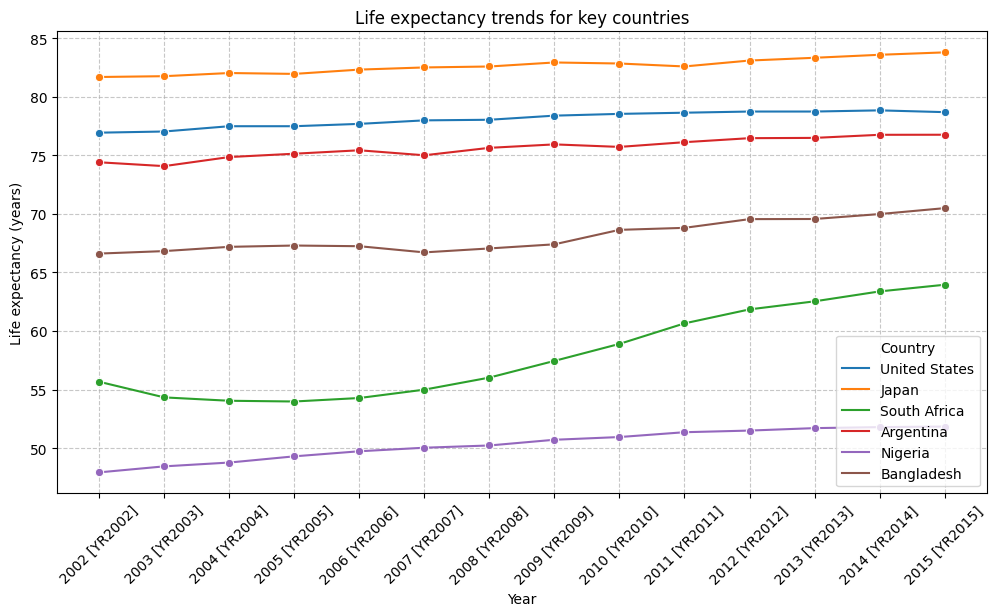

In [10]:
# Compare life expectancy trends for key countries
# Identify key countries
key_countries_list = ['Japan', 'United States', 'Argentina', 'Bangladesh', 'Nigeria', 'South Africa']

# Filter data for key countries and reshape data
key_countries_df = life_expectancy_df[life_expectancy_df['Country Name'].isin(key_countries_list)]
life_expectancy_melted = key_countries_df.melt(id_vars=['Country Name'], 
                                               value_vars=year_columns, 
                                               var_name="Year", 
                                               value_name="Life Expectancy")


# Plot 
plt.figure(figsize=(12,6))
sns.lineplot(data=life_expectancy_melted, x='Year', y='Life Expectancy', hue='Country Name', marker='o')

plt.title("Life expectancy trends for key countries")
plt.xlabel("Year")
plt.ylabel("Life expectancy (years)")
plt.legend(title="Country")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


- High-income: Japan, United States
- Middle-income: Argentina, Bangladesh
- Low-income: Nigeria, South Africa 
- We selected these countries as the most representative of their respective income groups. High-income countries like Japan and the U.S. show stable life expectancy trends with minimal fluctuations. Middle-income countries display steady growth over time. Low-income countries start at much lower baselines but show noticeable improvements but with more variability.

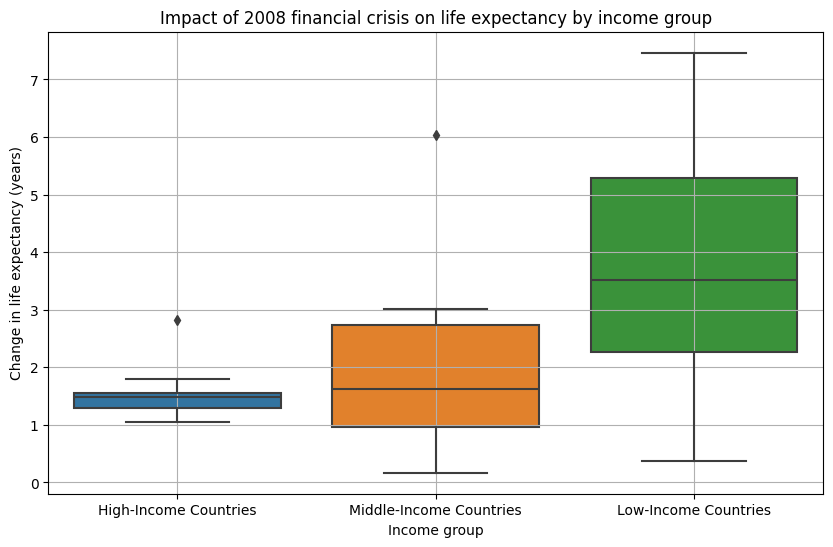

                         count      mean       std       min       25%  \
Income Group                                                             
High-Income Countries     11.0  1.532049  0.474928  1.051148  1.288415   
Low-Income Countries      11.0  3.870038  2.246473  0.376375  2.261750   
Middle-Income Countries   11.0  2.024409  1.639443  0.169417  0.956583   

                              50%       75%       max  
Income Group                                           
High-Income Countries    1.489939  1.553913  2.817175  
Low-Income Countries     3.520750  5.293938  7.464750  
Middle-Income Countries  1.619875  2.726896  6.042667  


In [ ]:
# Life expectancy before & after a global financial crisis of 2008

# Average life expectancy before and after 2008 financial crisis
train_df_filtered = train_df[train_df['Series Name'] == 'Life expectancy at birth, total (years)']

# pre and post 2008 averages
pre_2008 = train_df_filtered[['Country Name', 'Income Group'] + [col for col in year_columns if '2002' in col or '2003' in col or '2004' in col or '2005' in col or '2006' in col or '2007' in col]].set_index(['Country Name', 'Income Group']).mean(axis=1)
post_2008 = train_df_filtered[['Country Name', 'Income Group'] + [col for col in year_columns if '2008' in col or '2009' in col or '2010' in col or '2011' in col or '2012' in col or '2013' in col or '2014' in col or '2015' in col]].set_index(['Country Name', 'Income Group']).mean(axis=1)

# Create a dataframe
crisis_df = pd.DataFrame({'Pre-2008': pre_2008, 'Post-2008': post_2008}).reset_index()

# Difference
crisis_df['Change in Life Expectancy'] = crisis_df['Post-2008'] - crisis_df['Pre-2008']

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='Income Group', y='Change in Life Expectancy', data=crisis_df)
plt.title("Impact of 2008 financial crisis on life expectancy by income group")
plt.xlabel("Income group")
plt.ylabel("Change in life expectancy (years)")
plt.grid(True)
plt.show()

# Summary statistics
print(crisis_df.groupby('Income Group')['Change in Life Expectancy'].describe())


- Surprisingly, the 2008 financial crisis did not negatively impact life expectancy across income groups. Instead, all groups experienced positive changes, with low-income countries seeing the largest median increase and the widest range of impacts. Middle-income countries showed moderate gains with more variability, and high-income countries had the smallest but most stable increases. 
- This suggests that despite economic instability, healthcare improvements and other long-term trends are likely the main factors of increasing life expectancy.

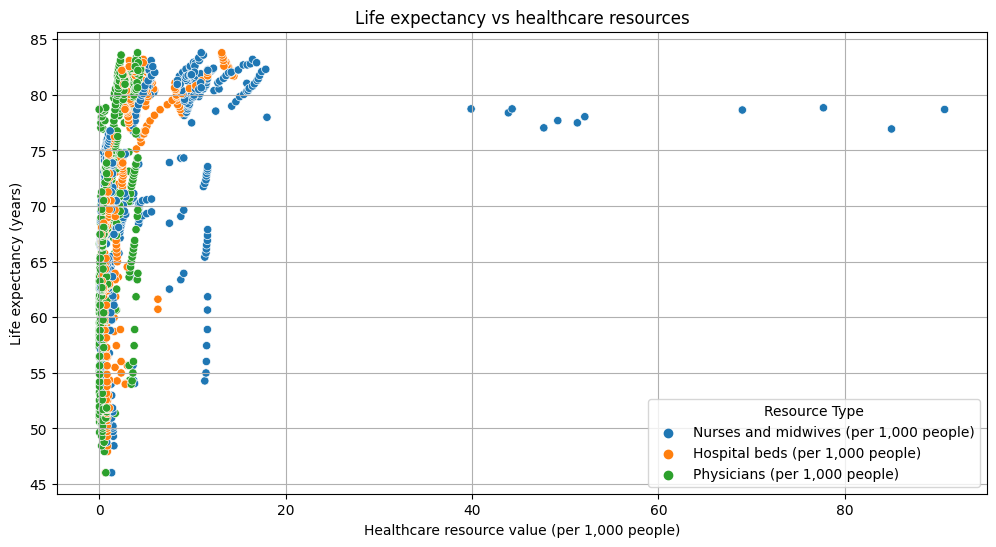

In [16]:
# Life expectancy vs healthcare resources
# Filter for life expectancy indicator and reshape the data
life_expectancy_df = train_df[train_df['Series Name'] == 'Life expectancy at birth, total (years)']
life_expectancy_melted = life_expectancy_df.melt(id_vars=['Country Name', 'Income Group'], 
                                                 value_vars=year_columns, 
                                                 var_name="Year", 
                                                 value_name="Life Expectancy")

# Convert 'year' to numeric
life_expectancy_melted['Year'] = life_expectancy_melted['Year'].str.extract('(\d+)').astype(int)

# Healthcare resource indicators
healthcare_resources = [
    'Physicians (per 1,000 people)', 
    'Hospital beds (per 1,000 people)', 
    'Nurses and midwives (per 1,000 people)'
]

# Filter the dataset for selected indicators
resource_df = train_df[train_df['Series Name'].isin(healthcare_resources)]

# Reshape data
resource_melted = resource_df.melt(id_vars=['Country Name', 'Series Name', 'Income Group'], 
                                   value_vars=year_columns, 
                                   var_name="Year", 
                                   value_name="Resource Value")

# Convert 'year' to numeric and merge with life expectancy data
resource_melted['Year'] = resource_melted['Year'].str.extract('(\d+)').astype(int)
merged_resource_df = resource_melted.merge(life_expectancy_melted, on=['Country Name', 'Year', 'Income Group'])

# Scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(data=merged_resource_df, x='Resource Value', y='Life Expectancy', hue='Series Name')
plt.title("Life expectancy vs healthcare resources")
plt.xlabel("Healthcare resource value (per 1,000 people)")
plt.ylabel("Life expectancy (years)")
plt.legend(title="Resource Type")
plt.grid(True)
plt.show()


- This graph shows the relationship between life expectancy and healthcare resources, specifically the number of nurses, hospital beds, and physicians per 1,000 people.
- At lower levels of healthcare resources, life expectancy increases rapidly, suggesting that even modest improvements in healthcare access significantly boost longevity. But after a certain threshold, adding more healthcare resources does not strongly correlate with higher life expectancy, showing a diminishing returns effect, where other healthcare factors become more influential.
- There are also outliers, where some countries have high healthcare resource availability but relatively lower life expectancy.

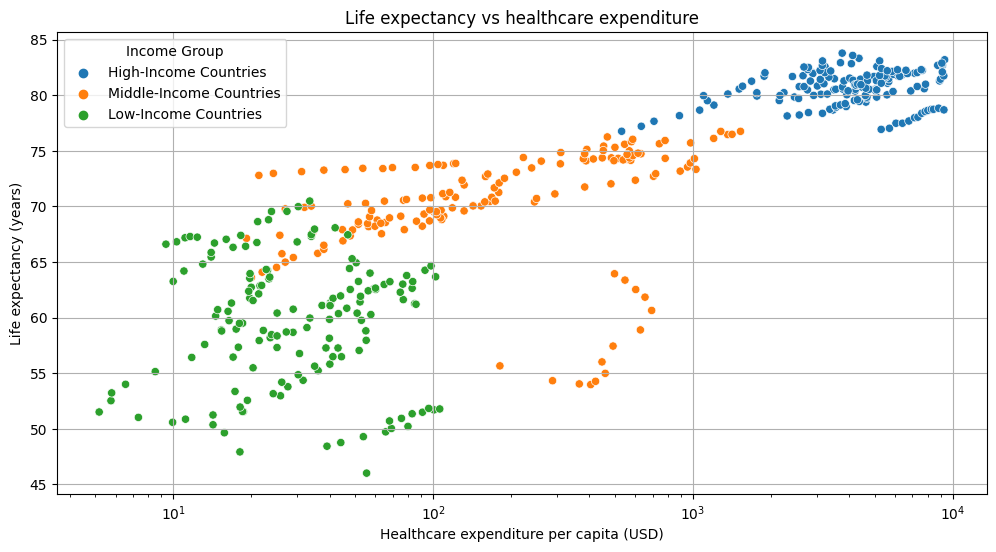

In [19]:
# Life expectancy vs healthcare expenditure
# Filter for life expectancy indicator and reshape the data
life_expectancy_df = train_df[train_df['Series Name'] == 'Life expectancy at birth, total (years)']
life_expectancy_melted = life_expectancy_df.melt(id_vars=['Country Name', 'Income Group'], 
                                                 value_vars=year_columns, 
                                                 var_name="Year", 
                                                 value_name="Life Expectancy")

# Convert 'year' to numeric
life_expectancy_melted['Year'] = life_expectancy_melted['Year'].str.extract('(\d+)').astype(int) 

# Filter healthcare expenditure indicator and reshape data
health_exp_df = train_df[train_df['Series Name'] == 'Current health expenditure per capita (current US$)']
health_exp_melted = health_exp_df.melt(id_vars=['Country Name', 'Income Group'], 
                                       value_vars=year_columns, 
                                       var_name="Year", 
                                       value_name="Health Expenditure")

# Convert 'year' to numeric and merge data
health_exp_melted['Year'] = health_exp_melted['Year'].str.extract('(\d+)').astype(int)
merged_exp_df = health_exp_melted.merge(life_expectancy_melted, on=['Country Name', 'Year', 'Income Group'])

# Scatter plot
plt.figure(figsize=(12,6))
sns.scatterplot(data=merged_exp_df, x='Health Expenditure', y='Life Expectancy', hue='Income Group')

plt.title("Life expectancy vs healthcare expenditure")
plt.xlabel("Healthcare expenditure per capita (USD)")
plt.ylabel("Life expectancy (years)")
plt.xscale("log")
plt.grid(True)
plt.show()


- This graph shows the relationship between life expectancy and healthcare expenditure per capita (USD) across different income groups.
- Similar to the healthcare resources graph, life expectancy increases sharply at lower spending levels, meaning that even small investments in healthcare can lead to significant improvements in health outcomes. However, beyond a certain threshold, around $1,000 per capita, the gains in life expectancy plateau, which indicates diminishing returns, where additional spending does not necessarily translate to longer life expectancy.
- The separation between income groups is clear. High-income countries cluster at the top with both high life expectancy and high healthcare spending. Low-income countries show a wider spread, with much lower spending and shorter life expectancy.
- There are also outliers, where some countries with relatively high healthcare spending still have lower life expectancy.

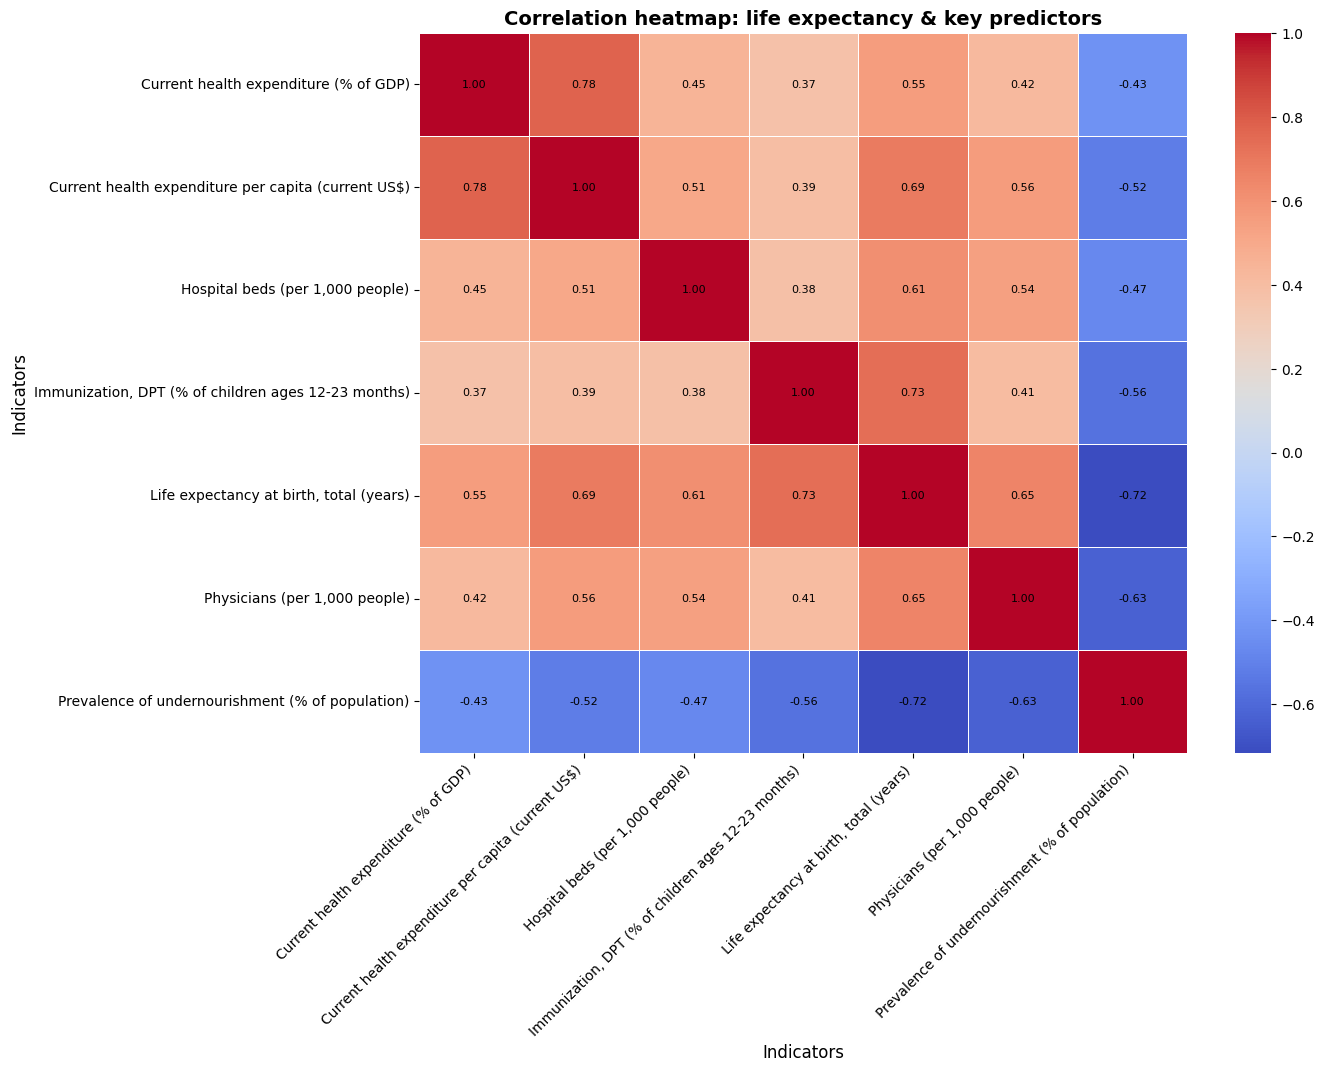

In [ ]:
# Heatmap: correlation between key variables
# List of indicators
heatmap_indicators = [
    'Life expectancy at birth, total (years)', 
    'Physicians (per 1,000 people)', 
    'Hospital beds (per 1,000 people)', 
    'Nurses and Midwives (per 1,000 people)',
    'Current health expenditure per capita (current US$)', 
    'Current health expenditure (% of GDP)', 
    'GDP per capita (current US$)', 
    'Unemployment rate (% of labor force)', 
    'Literacy rate (%)',
    'Access to essential medicines (% of population)',
    'Immunization, DPT (% of children ages 12-23 months)',
    'Improved water source (% of population with access)',
    'Improved sanitation facilities (% of population with access)',
    'Prevalence of undernourishment (% of population)',
    'Mortality rate, infant (per 1,000 live births)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'Population growth (annual %)'
]

# Filter dataset
heatmap_df = train_df[train_df['Series Name'].isin(heatmap_indicators)]
heatmap_melted = heatmap_df.melt(id_vars=['Country Name', 'Series Name'], 
                                                   value_vars=year_columns, 
                                                   var_name="Year", 
                                                   value_name="Value")

# Convert 'year' to numeric
heatmap_melted['Year'] = heatmap_melted['Year'].str.extract('(\d+)').astype(int)

# Pivot table to structure data
heatmap_pivot = heatmap_melted.pivot_table(index=['Country Name', 'Year'], 
                                                             columns='Series Name', 
                                                             values='Value')

# Compute correlation matrix
correlation_matrix = heatmap_pivot.corr()

# Handle NaN values
correlation_matrix = correlation_matrix.fillna(0)
correlation_matrix = correlation_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)

# Plot heatmap
plt.figure(figsize=(16, 12))  # Increase figure size
ax = sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Annotations
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        text = f"{correlation_matrix.iloc[i, j]:.2f}"
        ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=8, color='black')

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.subplots_adjust(left=0.3, bottom=0.3, right=0.9, top=0.9)
plt.title("Correlation heatmap: life expectancy & key predictors", fontsize=14, fontweight='bold')
plt.xlabel("Indicators", fontsize=12)
plt.ylabel("Indicators", fontsize=12)
plt.show()


- Immunization, healthcare expenditure per capita, and physicians per 1,000 people have the strongest positive correlations with life expectancy, meaning that access to medical professionals and preventative care can significantly improve longevity.
- Undernourishment has the strongest negative impact on life expectancy, which indicates that food insecurity directly limits health outcomes.
- Healthcare spending shows diminishing returns.Higher spending is linked to longer life expectancy, but the effect plateaus, as seen with healthcare expenditure as a percentage of GDP.
- Resource availability also correlates positively with life expectancy, meaning that greater access to healthcare infrastructure contributes to longer lifespans.

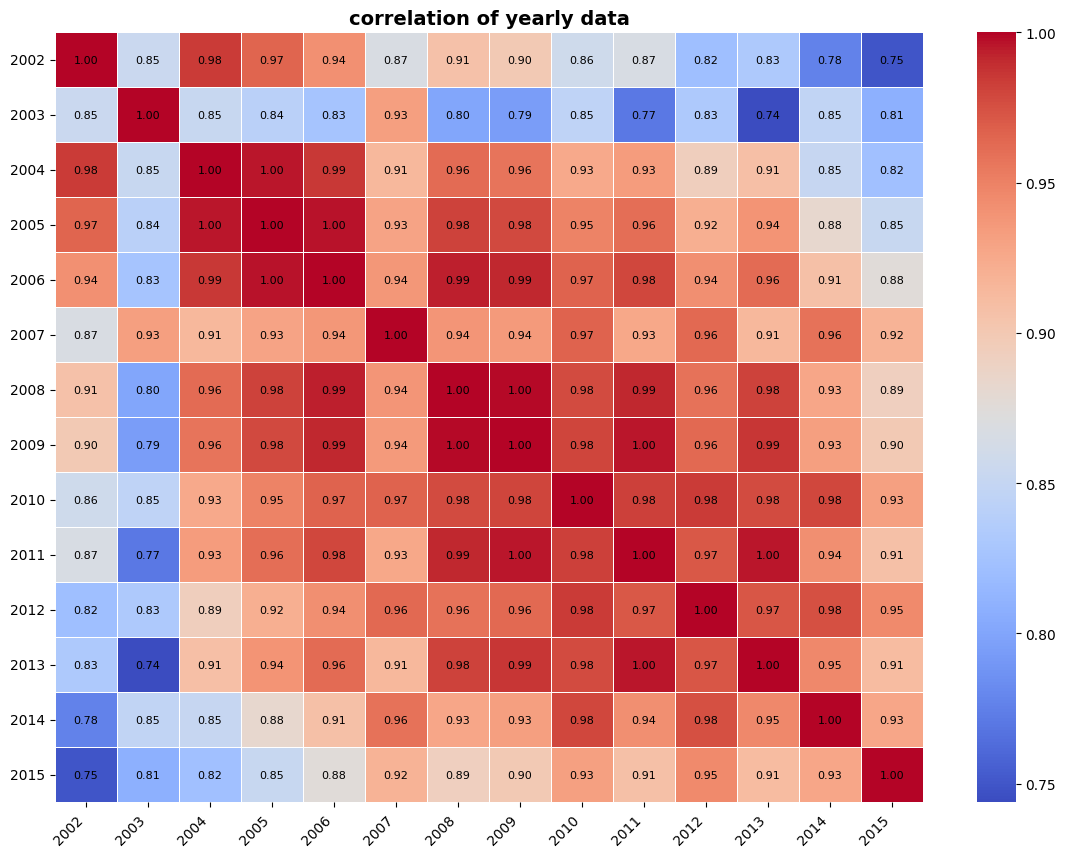

In [21]:
# Correlation of life expectancy trends over time
plt.figure(figsize=(14, 10))
ax = sns.heatmap(yearly_correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)

for i in range(yearly_correlation_matrix.shape[0]):
    for j in range(yearly_correlation_matrix.shape[1]):
        plt.text(j + 0.5, i + 0.5, f"{yearly_correlation_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', fontsize=8, color='black')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("correlation of yearly data", fontsize=14, fontweight='bold')

plt.show()


- Life expectancy values from adjacent years are highly correlated, showing consistency in trends over time.
- As the gap between years increases, correlation slightly decreases. This suggests that while life expectancy remains relatively stable over short periods long-term changes may introduce more variability,
- The earliest and latest years have lower correlations with other years, which may indicate shifts in global health trends affecting life expectancy over time.